# Cvičení 2: LOESS regrese a mnohonásobná lineární regrese


- **Úkol 1:** porovnání LOESS a polynomiální regrese na `Synthetic_dataset_1.csv`
- **Úkol 2:** mnohonásobná lineární regrese na `house_data.csv`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

import statsmodels.api as sm

sns.set_theme(style="whitegrid")

# Cesta ke složce s notebookem
BASE_DIR = Path.cwd()
print("Working directory:", BASE_DIR)

Working directory: c:\Users\tovis\Documents\GitHub\ujep\PSM\b2


In [4]:
# Pomocná funkce pro LOESS predikci (preferuje pyloess dle materiálů; fallback přes statsmodels)
def loess_predict(train_x, train_y, eval_x, span=0.75, degree=2):
    train_x = np.asarray(train_x).ravel()
    train_y = np.asarray(train_y).ravel()
    eval_x = np.asarray(eval_x).ravel()

    try:
        from pyloess import loess
        pred = loess(train_x, train_y, eval_x=eval_x, span=span, degree=degree)
        return np.asarray(pred).ravel(), "pyloess"
    except Exception:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        smooth = lowess(train_y, train_x, frac=span, it=0, return_sorted=True)
        x_sorted = smooth[:, 0]
        y_sorted = smooth[:, 1]
        pred = np.interp(eval_x, x_sorted, y_sorted)
        return pred, "statsmodels.lowess"

## Úkol 1: Porovnání LOESS a polynomiální regrese

Cíl: Porovnat predikční schopnost LOESS a polynomiální regrese pro modelování vztahu mezi atributy v datové sadě `Synthetic_dataset_1.csv` (cílová proměnná `Y`).

Shape: (300, 2)
      X      Y
0 -3.00  2.847
1 -2.98  2.073
2 -2.96  2.723
3 -2.94  3.464
4 -2.92  1.575


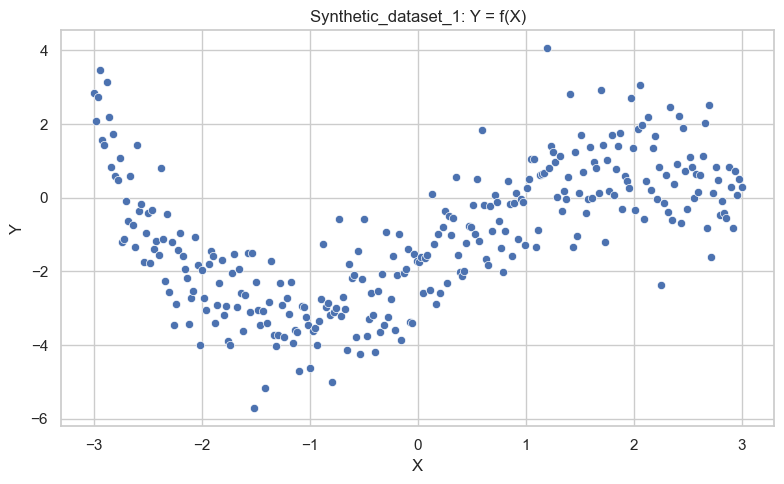

In [5]:
# 1) Načtení dat + základní kontrola
synthetic_path = BASE_DIR / "Synthetic_dataset_1.csv"
synthetic_df = pd.read_csv(synthetic_path)

print("Shape:", synthetic_df.shape)
print(synthetic_df.head())

X = synthetic_df[["X"]].values
y = synthetic_df["Y"].values

plt.figure(figsize=(8, 5))
sns.scatterplot(data=synthetic_df, x="X", y="Y", s=35)
plt.title("Synthetic_dataset_1: Y = f(X)")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

In [6]:
# 2) Rozdělení dat 70/30 (train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# V rámci train dat dále vytvoříme validační část pro volbu stupně polynomu
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Inner-train size:", X_train_inner.shape[0])
print("Validation size:", X_val.shape[0])

Train size: 210
Test size: 90
Inner-train size: 168
Validation size: 42


In [7]:
# 3) LOESS model trénovaný pouze na train datech
loess_span = 0.75
loess_degree = 2

y_test_pred_loess, loess_backend = loess_predict(
    train_x=X_train.ravel(),
    train_y=y_train,
    eval_x=X_test.ravel(),
    span=loess_span,
    degree=loess_degree,
)

rmse_loess = np.sqrt(mean_squared_error(y_test, y_test_pred_loess))
r2_loess = r2_score(y_test, y_test_pred_loess)

print("LOESS backend:", loess_backend)
print(f"LOESS test RMSE: {rmse_loess:.4f}")
print(f"LOESS test R^2:  {r2_loess:.4f}")

LOESS backend: pyloess
LOESS test RMSE: 0.8904
LOESS test R^2:  0.7743


In [8]:
# 4) Polynomiální regrese: výběr stupně pomocí validačního RMSE
degrees = list(range(2, 11))
val_results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_inner_poly = poly.fit_transform(X_train_inner)
    X_val_poly = poly.transform(X_val)

    model_poly = LinearRegression()
    model_poly.fit(X_train_inner_poly, y_train_inner)

    y_val_pred = model_poly.predict(X_val_poly)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_results.append((degree, rmse_val))

val_results_df = pd.DataFrame(val_results, columns=["degree", "val_rmse"])
best_degree = int(val_results_df.loc[val_results_df["val_rmse"].idxmin(), "degree"])

print(val_results_df)
print(f"Best polynomial degree by validation RMSE: {best_degree}")

   degree  val_rmse
0       2  1.355935
1       3  0.991720
2       4  1.012758
3       5  1.025680
4       6  0.996668
5       7  0.988851
6       8  0.980173
7       9  0.987146
8      10  0.994134
Best polynomial degree by validation RMSE: 8


In [9]:
# Refit nejlepšího polynomu na celém train setu + vyhodnocení na test setu
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly_best = poly_best.fit_transform(X_train)
X_test_poly_best = poly_best.transform(X_test)

poly_model_best = LinearRegression()
poly_model_best.fit(X_train_poly_best, y_train)

y_test_pred_poly = poly_model_best.predict(X_test_poly_best)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"Polynomial (degree={best_degree}) test RMSE: {rmse_poly:.4f}")
print(f"Polynomial (degree={best_degree}) test R^2:  {r2_poly:.4f}")

Polynomial (degree=8) test RMSE: 0.8821
Polynomial (degree=8) test R^2:  0.7785


In [10]:
# 5) Srovnávací tabulka metrik na test setu
task1_results = pd.DataFrame([
    {"Model": f"LOESS ({loess_backend})", "RMSE": rmse_loess, "R2": r2_loess},
    {"Model": f"Polynomial degree={best_degree}", "RMSE": rmse_poly, "R2": r2_poly},
]).sort_values("RMSE")

print(task1_results)

                 Model      RMSE        R2
1  Polynomial degree=8  0.882123  0.778535
0      LOESS (pyloess)  0.890443  0.774338


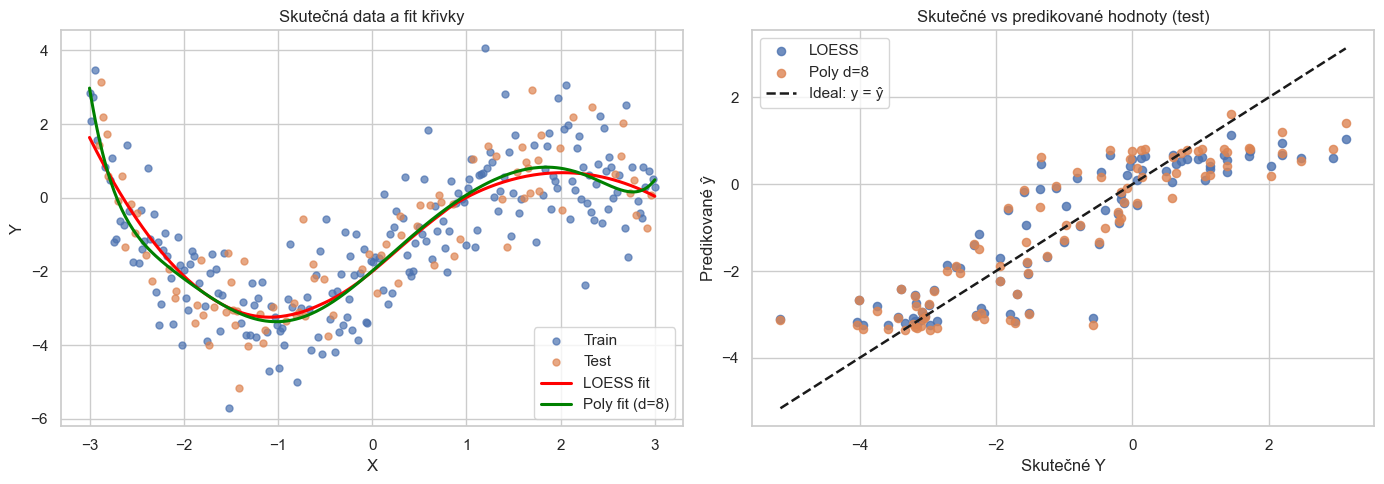

In [11]:
# 6) Vizuální porovnání skutečných a predikovaných hodnot
x_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_grid_loess, _ = loess_predict(X_train.ravel(), y_train, x_grid.ravel(), span=loess_span, degree=loess_degree)
y_grid_poly = poly_model_best.predict(poly_best.transform(x_grid))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Data + fitted curves
axes[0].scatter(X_train, y_train, s=25, alpha=0.7, label="Train")
axes[0].scatter(X_test, y_test, s=25, alpha=0.7, label="Test")
axes[0].plot(x_grid, y_grid_loess, color="red", linewidth=2.2, label="LOESS fit")
axes[0].plot(x_grid, y_grid_poly, color="green", linewidth=2.2, label=f"Poly fit (d={best_degree})")
axes[0].set_title("Skutečná data a fit křivky")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].legend()

# (b) Actual vs Predicted na test setu
axes[1].scatter(y_test, y_test_pred_loess, s=35, alpha=0.8, label="LOESS")
axes[1].scatter(y_test, y_test_pred_poly, s=35, alpha=0.8, label=f"Poly d={best_degree}")
min_y, max_y = y_test.min(), y_test.max()
axes[1].plot([min_y, max_y], [min_y, max_y], "k--", linewidth=1.8, label="Ideal: y = ŷ")
axes[1].set_title("Skutečné vs predikované hodnoty (test)")
axes[1].set_xlabel("Skutečné Y")
axes[1].set_ylabel("Predikované ŷ")
axes[1].legend()

plt.tight_layout()
plt.show()

**Diskuse (Úkol 1):**

- **LOESS** je neparametrický lokální model, který se flexibilně přizpůsobuje lokálním změnám trendu.
- **Polynomiální regrese** je parametrický globální model, který předpokládá jeden funkční tvar v celém rozsahu dat.
- LOESS bývá vhodnější při složitějších lokálních nelinearitách, zatímco polynomiální regrese je obvykle jednodušší na interpretaci díky explicitní rovnici modelu.

## Úkol 2: Mnohonásobná lineární regrese

- Datová sada: `house_data.csv`
- Cílová proměnná: `MEDV`

In [12]:
# 1) EDA: načtení dat, cílová proměnná, chybějící hodnoty
house_path = BASE_DIR / "house_data.csv"
house_df = pd.read_csv(house_path)

print("Shape:", house_df.shape)
print(house_df.head())
print("\nMissing values per column:\n", house_df.isnull().sum())

target_col = "MEDV"
predictor_cols = [c for c in house_df.columns if c != target_col]

print("\nTarget:", target_col)
print("Predictors count:", len(predictor_cols))

Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS     NX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Missing values per column:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NX         0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Target: MEDV
Predictors count: 13


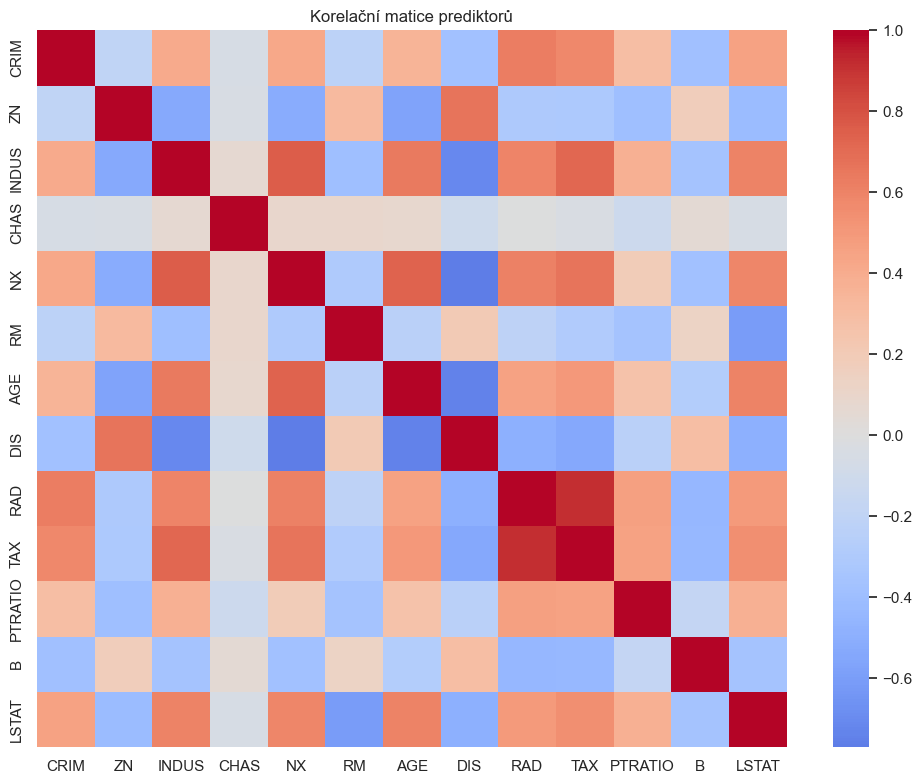

Silně korelované dvojice (|corr| >= 0.70):
   pred1 pred2    |corr|
6    RAD   TAX  0.910228
4     NX   DIS  0.769230
0  INDUS    NX  0.763651
5    AGE   DIS  0.747881
3     NX   AGE  0.731470
2  INDUS   TAX  0.720760
1  INDUS   DIS  0.708027


In [13]:
# 2) Diagnostika prediktorů: korelační matice + multikolinearita
corr_predictors = house_df[predictor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_predictors, cmap="coolwarm", center=0)
plt.title("Korelační matice prediktorů")
plt.tight_layout()
plt.show()

abs_corr = corr_predictors.abs()
strong_pairs = []
for i, c1 in enumerate(predictor_cols):
    for c2 in predictor_cols[i+1:]:
        val = abs_corr.loc[c1, c2]
        if val >= 0.70:
            strong_pairs.append((c1, c2, val))

strong_pairs_df = pd.DataFrame(strong_pairs, columns=["pred1", "pred2", "|corr|"]).sort_values("|corr|", ascending=False)
print("Silně korelované dvojice (|corr| >= 0.70):")
print(strong_pairs_df if not strong_pairs_df.empty else "Žádné")

Krátký komentář k multikolinearitě:

- Vysoké absolutní korelace mezi prediktory (např. $|corr| \geq 0.70$) mohou signalizovat multikolinearitu.
- Důsledkem mohou být nestabilní odhady jednotlivých koeficientů (vyšší směrodatné chyby), i když celková predikce modelu může zůstat dobrá.
- Posouzení významnosti proto doplňujeme inferenčním výstupem OLS (`t` testy, `F` test, adjusted $R^2$).

In [14]:
# 3) Rozdělení dat 70/30
X_house = house_df[predictor_cols]
y_house = house_df[target_col]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.30, random_state=42
)

print("Train size:", X_train_h.shape[0])
print("Test size:", X_test_h.shape[0])

Train size: 354
Test size: 152


In [20]:
# 4) Odhad parametrů modelu na train setu (sklearn)
mlr_model = LinearRegression()
mlr_model.fit(X_train_h, y_train_h)

coef_table = pd.DataFrame({
    "predictor": predictor_cols,
    "coefficient": mlr_model.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

print("Intercept:", mlr_model.intercept_)
print(coef_table)

Intercept: 31.63108403569313
   predictor  coefficient
4         NX   -15.417061
5         RM     4.057199
3       CHAS     3.119835
7        DIS    -1.385998
10   PTRATIO    -0.910685
12     LSTAT    -0.547113
8        RAD     0.242727
0       CRIM    -0.133470
2      INDUS     0.049523
1         ZN     0.035809
11         B     0.011794
6        AGE    -0.010821
9        TAX    -0.008702


In [21]:
# 5) Statistická interpretace: explicitní t-testy koeficientů, F-test modelu, adjusted R^2
alpha = 0.05

X_train_h_sm = sm.add_constant(X_train_h)
ols_model = sm.OLS(y_train_h, X_train_h_sm).fit()

# Kompletní OLS výstup
print(ols_model.summary())

# --- t-testy jednotlivých koeficientů ---
coef_tests = pd.DataFrame({
    "coef": ols_model.params,
    "std_err": ols_model.bse,
    "t_value": ols_model.tvalues,
    "p_value": ols_model.pvalues,
})
coef_tests["reject_H0_beta_eq_0"] = coef_tests["p_value"] < alpha

print(f"\nT-testy koeficientů (alpha = {alpha}):")
print(coef_tests)

# Významné prediktory bez interceptu
significant_predictors = coef_tests.drop(index="const", errors="ignore")
significant_predictors = significant_predictors[significant_predictors["reject_H0_beta_eq_0"]]
pvals = ols_model.pvalues.drop("const", errors="ignore")

print("\nVýznamné prediktory (p < 0.05):")
print(significant_predictors if not significant_predictors.empty else "Žádné")

# --- F-test celého modelu ---
f_stat = float(ols_model.fvalue)
f_pvalue = float(ols_model.f_pvalue)
reject_f_test = f_pvalue < alpha

print("\nF-test celého modelu:")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {f_pvalue:.6g}")
print("Rozhodnutí:", "Zamítáme H0 (model je celkově významný)." if reject_f_test else "Nezamítáme H0 (model není celkově významný).")

# --- adjusted R^2 ---
print(f"\nAdjusted R^2 = {ols_model.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     75.81
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           4.96e-92
Time:                        16:57:30   Log-Likelihood:                -1053.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     340   BIC:                             2190.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.6311      6.056      5.223      0.0

House model test RMSE: 4.6387
House model test R^2:  0.7112


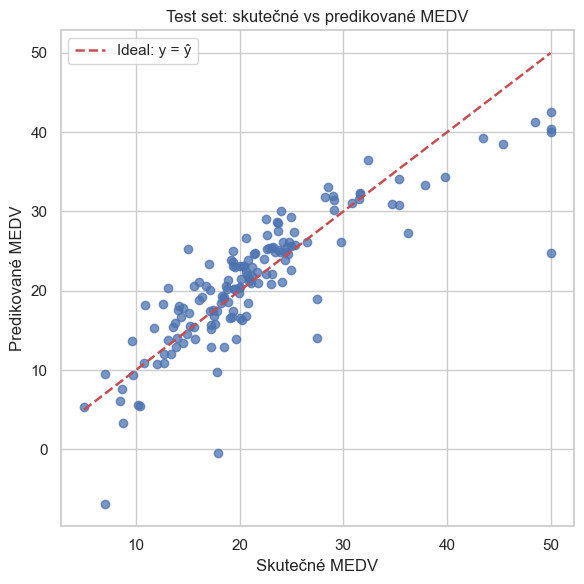

In [22]:
# 6) Predikční hodnocení na test setu: RMSE, R^2
y_test_pred_h = mlr_model.predict(X_test_h)

rmse_h = np.sqrt(mean_squared_error(y_test_h, y_test_pred_h))
r2_h = r2_score(y_test_h, y_test_pred_h)

print(f"House model test RMSE: {rmse_h:.4f}")
print(f"House model test R^2:  {r2_h:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_h, y_test_pred_h, alpha=0.75)
min_v, max_v = y_test_h.min(), y_test_h.max()
plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.8, label="Ideal: y = ŷ")
plt.xlabel("Skutečné MEDV")
plt.ylabel("Predikované MEDV")
plt.title("Test set: skutečné vs predikované MEDV")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# 7) Souhrnná tabulka inferenčních i predikčních metrik
task2_summary = pd.DataFrame([{
    "F_statistic": f_stat,
    "F_p_value": f_pvalue,
    "F_test_reject_H0_alpha_0_05": reject_f_test,
    "Adjusted_R2_train": ols_model.rsquared_adj,
    "Test_RMSE": rmse_h,
    "Test_R2": r2_h,
}])

print("Task 2 summary table:")
print(task2_summary.round(6))

Task 2 summary table:
   F_statistic  F_p_value  F_test_reject_H0_alpha_0_05  Adjusted_R2_train  \
0    75.810368        0.0                         True           0.733692   

   Test_RMSE   Test_R2  
0    4.63869  0.711226  


**Interpretace (Úkol 2):**

- **t-test koeficientů:** v předchozím kroku jsou pro každý koeficient vypsány hodnoty `t`, `p` a rozhodnutí o zamítnutí $H_0: \beta_i = 0$ při $\alpha = 0.05$.
- **F-test modelu:** je explicitně vypsána hodnota `F-statistic`, `p-value` a rozhodnutí pro $H_0$: všechny sklonové koeficienty jsou nulové.
- **Adjusted $R^2$:** doplňuje kvalitu vysvětlení variability s penalizací za počet prediktorů.
- **Test RMSE a $R^2$:** ukazují predikční schopnost modelu na dříve neviděných datech.

## Závěr

Notebook obsahuje kompletní řešení obou úkolů:

1. Porovnání LOESS a polynomiální regrese (split 70/30, výběr stupně podle validačního RMSE, test RMSE/$R^2$, vizualizace a diskuse).
2. Mnohonásobná lineární regrese na datech `house_data.csv` (EDA, korelační diagnostika, odhad parametrů, `t`/`F`/adjusted $R^2$, test RMSE/$R^2$).